In [1]:
import torch
import numpy as np
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from datasets import load_dataset
from huggingface_hub import list_repo_files

In [2]:
files = list_repo_files("HuggingFaceM4/WebSight", repo_type="dataset")
train_files = [f"https://huggingface.co/datasets/HuggingFaceM4/WebSight/resolve/main/{f}"
               for f in files if "data/train" in f and f.endswith(".parquet")]

In [3]:
dataset = load_dataset("parquet", data_files={"train": train_files[:3]})

Generating train split: 0 examples [00:00, ? examples/s]

In [4]:
dataset_xs = dataset["train"].shard(num_shards=100, index=0)

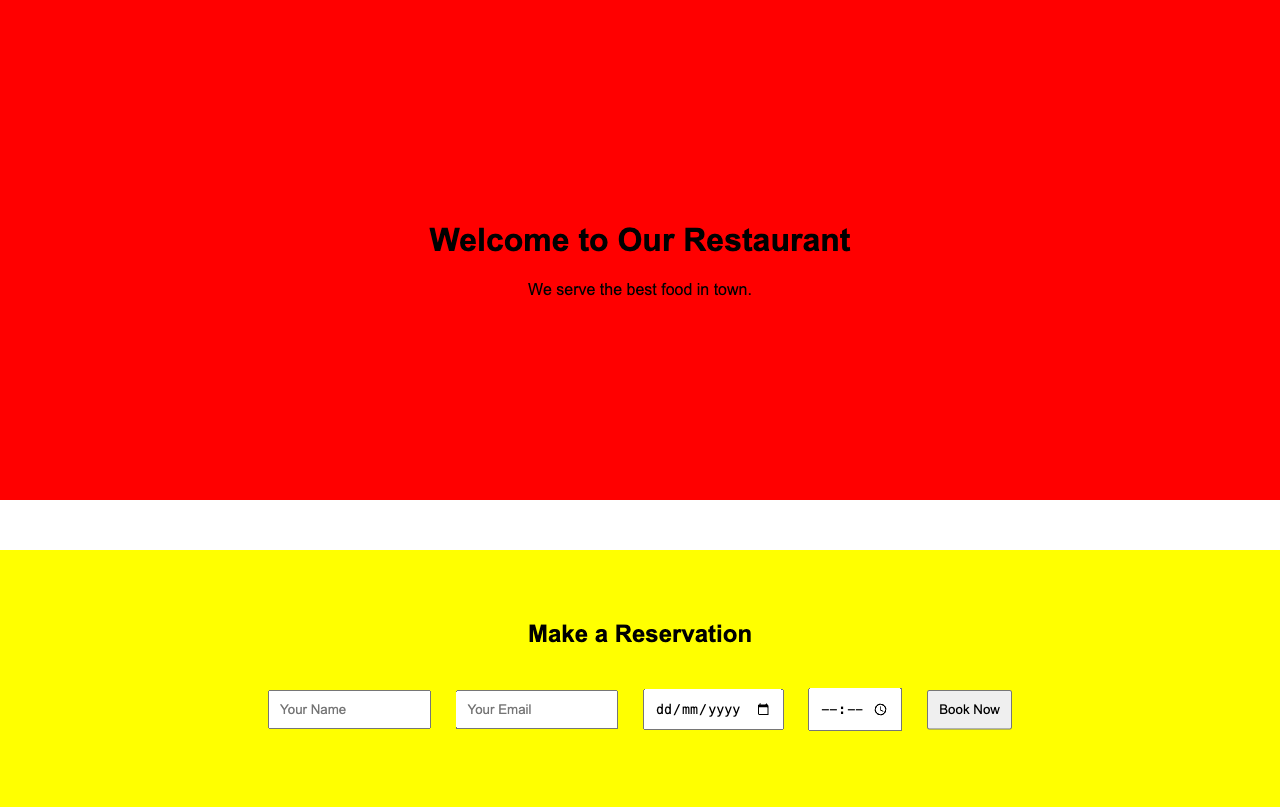

In [5]:
sample_img = dataset_xs[1]["image"]
sample_img

In [4]:
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig, PreTrainedModel, PretrainedConfig
from transformers import Blip2Model, Blip2Processor
from transformers import Trainer, TrainingArguments

In [5]:
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

In [6]:
class ImageTextCollator:
    def __init__(self, blip_processor, qwen_tokenizer):
        self.blip_processor = blip_processor
        self.qwen_tokenizer = qwen_tokenizer

    def __call__(self, batch):
        images = [x["image"] for x in batch]
        html = [x["text"] for x in batch]
        # ocr = [x["ocr"] for x in batch]

        blip_inputs = self.blip_processor(images=images, return_tensors="pt")
        qwen_html_inputs = self.qwen_tokenizer(html, return_tensors="pt", padding="longest")
        # qwen_ocr_inputs = self.qwen_tokenizer(ocr, return_tensors="pt", padding="longest")

        return {
            "pixel_values": blip_inputs["pixel_values"],
            "html_ids": qwen_html_inputs["input_ids"],
            # "ocr_ids": qwen_ocr_inputs["input_ids"]
        }

In [7]:
class ImageTextConfig(PretrainedConfig):
    model_type = "image_text_model"

    def __init__(
        self,
        blip_model_name=None,
        qwen_model_name=None,
        quantization_config=None,
        lora_config=None,
        prompt="answer only in html",
        proj_hidden_size=None,   # optional: hidden dim for projection if different
        **kwargs
    ):
        super().__init__(**kwargs)

        # Paths / identifiers for the pretrained models
        self.blip_model_name = blip_model_name
        self.qwen_model_name = qwen_model_name

        # Configs for quantization / LoRA
        self.quantization_config = quantization_config
        self.lora_config = lora_config

        # Prompt text
        self.prompt = prompt

        # Projection layer dimension (optional, inferred from models if None)
        self.proj_hidden_size = proj_hidden_size

In [8]:
class ImageTextModel(PreTrainedModel):
    config_class = ImageTextConfig

    def __init__(self, config: ImageTextConfig):
        super().__init__(config)

        self.blip_model = Blip2Model.from_pretrained(
            config.blip_model_name,
            quantization_config=config.quantization_config,
            device_map="auto"
        )
        self.qwen_model = AutoModelForCausalLM.from_pretrained(
            config.qwen_model_name,
            quantization_config=config.quantization_config,
            device_map="auto"
        )
        self.qwen_model = prepare_model_for_kbit_training(self.qwen_model, use_gradient_checkpointing=True)
        self.qwen_model.gradient_checkpointing_enable()
        self.qwen_model = get_peft_model(self.qwen_model, config.lora_config)

        self.blip_tokenizer = Blip2Processor.from_pretrained(config.blip_model_name)
        self.tokenizer = AutoTokenizer.from_pretrained(config.qwen_model_name)
        self.proj = nn.Linear(self.blip_model.config.qformer_config.hidden_size, self.qwen_model.config.hidden_size)

        for p in self.blip_model.parameters():
            p.requires_grad = False

        prompt_ids = self.tokenizer(config.prompt, return_tensors="pt").input_ids.to(self.qwen_model.device)
        self.prompt_embeds = self.qwen_model.get_input_embeddings()(prompt_ids)


    def get_image_embeds(self, pixel_values):
        qformer_embeds = self.blip_model.get_qformer_features(pixel_values, return_dict=True).last_hidden_state.to(self.device)
        image_embeds = self.proj(qformer_embeds)
        return image_embeds

    def forward(self, pixel_values, html_ids, ocr_ids=None):
        batch_size = pixel_values.shape[0]
        pixel_values=pixel_values.to(self.device)
        html_ids = html_ids.to(self.device)
        image_embeds = self.get_image_embeds(pixel_values)
        

        # crafting the input
        prompt_expanded = self.prompt_embeds.expand(batch_size, -1, -1)
        html_embeds = self.qwen_model.get_input_embeddings()(html_ids)

        if ocr_ids is not None:
            ocr_embeds = self.qwen_model.get_input_embeddings()(ocr_ids)
            input_embeds = torch.cat([prompt_expanded, image_embeds, ocr_embeds], dim=1)
        else:
            input_embeds = torch.cat([prompt_expanded, image_embeds], dim=1)

        ignore_prefix = torch.full(
            (batch_size, input_embeds.shape[1]), -100, dtype=torch.long, device=html_ids.device
        )
        if html_ids is not None: #training
            input_embeds = torch.cat([input_embeds, html_embeds], dim=1)
            labels = torch.cat([ignore_prefix, html_ids], dim=1)
            outputs = self.qwen_model(
                inputs_embeds=input_embeds,
                labels=labels
            )
            return outputs
        else: #generation
            outputs = self.qwen_model(inputs_embeds=input_embeds)
            return outputs

In [9]:
blip_model_name = "Salesforce/blip2-flan-t5-xl"
qwen_model_name = "Qwen/Qwen3-4B-Instruct-2507"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=False,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16
)
lora_config = LoraConfig(
    r=4, lora_alpha=16, lora_dropout=0.05, bias="none",
    task_type="CAUSAL_LM",
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_up_proj", "down_proj"]
)

config = ImageTextConfig(blip_model_name, qwen_model_name, bnb_config, lora_config)



In [10]:
model = ImageTextModel(config)
for p in model.parameters():
    p.requires_grad = False
for n, p in model.qwen_model.named_parameters():
    if "lora_" in n:
        p.requires_grad = True
for p in model.proj.parameters():
    p.requires_grad = True

print("Trainable params:",
      sum(p.numel() for p in model.parameters() if p.requires_grad) / 1e6, "M")

blip_processor = Blip2Processor.from_pretrained(blip_model_name)
collator = ImageTextCollator(blip_processor, model.tokenizer)

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


Trainable params: 6.687232 M


In [13]:
model = model.to("cuda")

In [ ]:
training_args = TrainingArguments(
    output_dir="./results",
    per_device_train_batch_size=4,
    gradient_accumulation_steps=4,
    learning_rate=15e-5,
    num_train_epochs=1,
    warmup_steps=20,
    logging_steps=10,
    save_strategy="steps",
    save_steps=100,
    max_steps=500,
    report_to="none",             # turn off W&B/other loggers
    remove_unused_columns=False,
    bf16=True
)
# Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset["train"],
    data_collator=collator,
)

# Train
trainer.train()

# Save
trainer.save_model("./final_model")

Step,Training Loss
10,1.173500


In [ ]:
tokenizer = processor.tokenizer

In [ ]:
messages = [
    {
        "role": "user",
        "content": [
            {"type": "image"},
            {"type": "text", "text": "describe the image"},
        ],
    },
]
image = sample_img

text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
inputs = processor(text=[text], images=[image], return_tensors="pt").to("cuda")

# Generate
generate_ids = model.generate(inputs.input_ids, max_new_tokens=1500)
tokenizer.batch_decode(generate_ids, skip_special_tokens=True, clean_up_tokenization_spaces=False)[0]

KeyboardInterrupt: 

In [ ]:
content

' for a website.\n\n<!DOCTYPE html>\n<html lang="en">\n<head>\n    <meta charset="UTF-8">\n    <meta name="viewport" content="width=device-width, initial-scale=1.0">\n    <title>Intro Page</title>\n</head>\n<body>\n    <h1>Welcome to Our Website</h1>\n    <p>This is a simple intro page for a website.</p>\n</body>\n</html>'

In [12]:
import gc, torch

gc.collect()             # ask Python to clear unreachable objects
torch.cuda.empty_cache()